In [7]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
folder_path = "/root/so-vits-svc/dataset_raw/kono_wav" 
data = []
example_audio = None
example_sr = None
example_filename = None

# Collect statistics from all .wav files
for file in os.listdir(folder_path):
    if file.lower().endswith('.wav'):
        filepath = os.path.join(folder_path, file)
        try:
            y, sr = librosa.load(filepath, sr=None, mono=False)
            duration = librosa.get_duration(y=y, sr=sr)
            channels = 1 if len(y.shape) == 1 else y.shape[0]
            data.append({
                'filename': file,
                'sampling_rate': sr,
                'channels': channels,
                'duration_sec': duration
            })
            # Save first audio for waveform and spectrogram
            if example_audio is None:
                example_audio = y
                example_sr = sr
                example_filename = file
        except Exception as e:
            print(f"Error loading {file}: {e}")

df = pd.DataFrame(data)

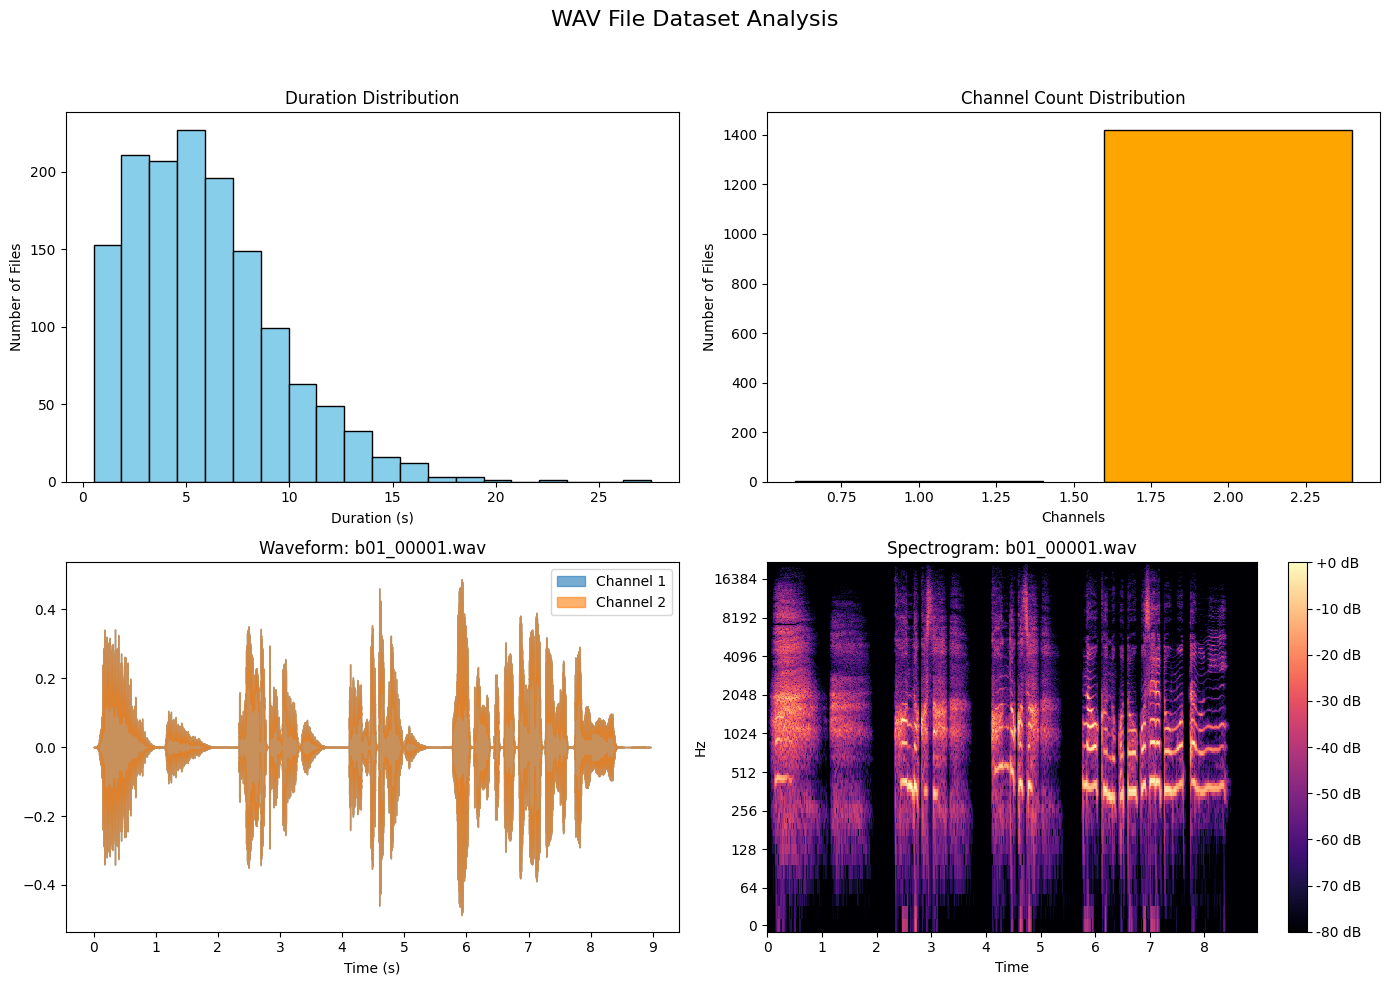

In [9]:
# === Create 2x2 figure layout ===
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("WAV File Dataset Analysis", fontsize=16)

# Duration histogram
axs[0, 0].hist(df['duration_sec'], bins=20, color='skyblue', edgecolor='black')
axs[0, 0].set_title('Duration Distribution')
axs[0, 0].set_xlabel('Duration (s)')
axs[0, 0].set_ylabel('Number of Files')

# Channel count distribution
axs[0, 1].bar(df['channels'].value_counts().sort_index().index,
                df['channels'].value_counts().sort_index().values,
                color='orange', edgecolor='black')
axs[0, 1].set_title('Channel Count Distribution')
axs[0, 1].set_xlabel('Channels')
axs[0, 1].set_ylabel('Number of Files')

# Waveform
if example_audio is not None:
    axs[1, 0].set_title(f"Waveform: {example_filename}")
    if len(example_audio.shape) == 1:
        librosa.display.waveshow(example_audio, sr=example_sr, ax=axs[1, 0])
    else:
        librosa.display.waveshow(example_audio[0], sr=example_sr, ax=axs[1, 0], label='Channel 1', alpha=0.6)
        librosa.display.waveshow(example_audio[1], sr=example_sr, ax=axs[1, 0], label='Channel 2', alpha=0.6)
        axs[1, 0].legend()
    axs[1, 0].set_xlabel('Time (s)')

# Spectrogram
if example_audio is not None:
    D = librosa.amplitude_to_db(np.abs(librosa.stft(example_audio[0] if len(example_audio.shape) > 1 else example_audio)), ref=np.max)
    img = librosa.display.specshow(D, sr=example_sr, x_axis='time', y_axis='log', ax=axs[1, 1])
    axs[1, 1].set_title(f"Spectrogram: {example_filename}")
    fig.colorbar(img, ax=axs[1, 1], format="%+2.f dB")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()